# Experiment 1 — statistical analysis (PD)

How do the learners compare on **PD** (metric: **AUC**), across datasets, in a statistically defensible way? We follow the standard cross-dataset comparison framework (Demšar, 2006) and its successors, read as a story:

1. **PAMA** — who wins most often (descriptive).
2. **Omnibus tests** — do the methods differ *at all*?
3. **Critical-difference diagram** — which groups are indistinguishable.
4. **Win/Loss matrix** — the direction of every head-to-head.
5. **Significant pairs** — Wilcoxon *and* t-test, both Holm-corrected.
6. **Adjusted-p-value matrix** — the same, as a colour map.
7. **Bayesian ROPE analysis** — the *practical* probability of superiority.

All results here use the **HPO** runs (the tuned configuration of each method). Logic lives in `src/utils/statistical_testing.py`; this notebook narrates and calls it.

In [1]:
import sys
from pathlib import Path
PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.utils.paths import results_root
from src.visualizations.experiment_plots import apply_style, reset_figure_dir, load_summary
from src.methods.method_config import FOUNDATION_METHODS
from src.utils import statistical_testing as st
from src.utils.report import notebook_report, capture, section
apply_style()

RESULTS_ROOT = results_root()
SUMMARY_DIR  = RESULTS_ROOT / 'summaries'
FIGURES_DIR  = reset_figure_dir(PROJECT_ROOT / 'figures' / 'experiment1' / 'pd_stats')
FND = sorted(FOUNDATION_METHODS)


In [2]:
df       = load_summary(SUMMARY_DIR, experiment='experiment1', task='pd', hpo_mode='HPO')
df_folds = load_summary(SUMMARY_DIR, experiment='experiment1', task='pd', aggregated=False, hpo_mode='HPO')
mat  = st.metric_matrix(df, 'AUC')
ranks = st.average_ranks(mat)              # best-first ordering reused everywhere


## 1. PAMA — how often is each learner the single best?

**What it is.** For every fold-level observation (each dataset × fold), which method scored highest? **Why it matters.** A direct, assumption-free measure of *practical dominance*, robust to outlying datasets. **How to read it.** Taller bar = wins more often; foundation models in red, with their *collective* share annotated.

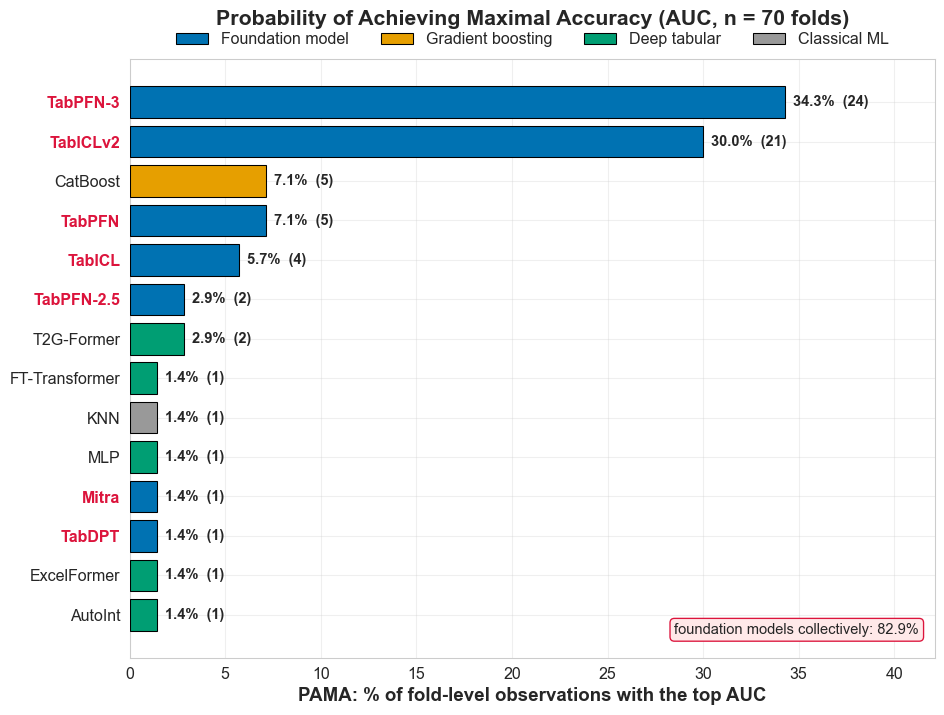

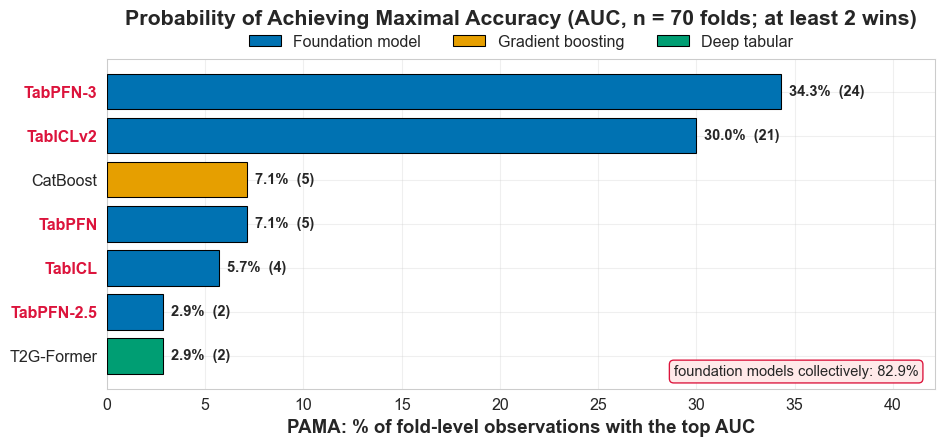

WindowsPath('C:/Users/U0152019/PhD Documents/Projects/1. TabPFN/TabPFNCredit/figures/experiment1/pd_stats/pd_pama_min2wins.pdf')

In [3]:
st.plot_pama_bars(df_folds, 'AUC', metric_name='AUC', foundation_methods=FND,
                  out_path=FIGURES_DIR / 'pd_pama.pdf')
# Same PAMA, but only the methods that are the single best on >= 2 (dataset, fold)
# observations -- drops the one-off winners for a cleaner ranking of real contenders.
st.plot_pama_bars(df_folds, 'AUC', metric_name='AUC', foundation_methods=FND,
                  min_wins=2, out_path=FIGURES_DIR / 'pd_pama_min2wins.pdf')


## 2. Do the methods differ at all? — Friedman omnibus test

**What it is.** The Friedman test ranks methods within each dataset and tests whether the *average ranks* depart from equality; the **Iman–Davenport** F-correction is less conservative. **How to read it.** A small p-value rejects "all methods are equal" and licenses the post-hoc comparisons that follow.

In [4]:
f = st.friedman_test(mat)


## 3. More powerful omnibus alternatives — Aligned Ranks & Quade

**Why.** With many methods but few datasets, the plain Friedman test loses power. The **Friedman Aligned Ranks** and **Quade** tests (García et al., 2010) recover power. **How to read it.** Agreement with Friedman means the global signal is robust.

In [5]:
fa = st.friedman_aligned_ranks_test(mat); qu = st.quade_test(mat)


## 4. Which methods are indistinguishable? — critical-difference diagram

**What it is.** Methods on the average-rank axis (rank 1 = best, left). Two methods whose ranks differ by less than the **critical difference (CD)** are not significantly different (Nemenyi, α = 0.05) and are joined by a bar. Foundation models in red.

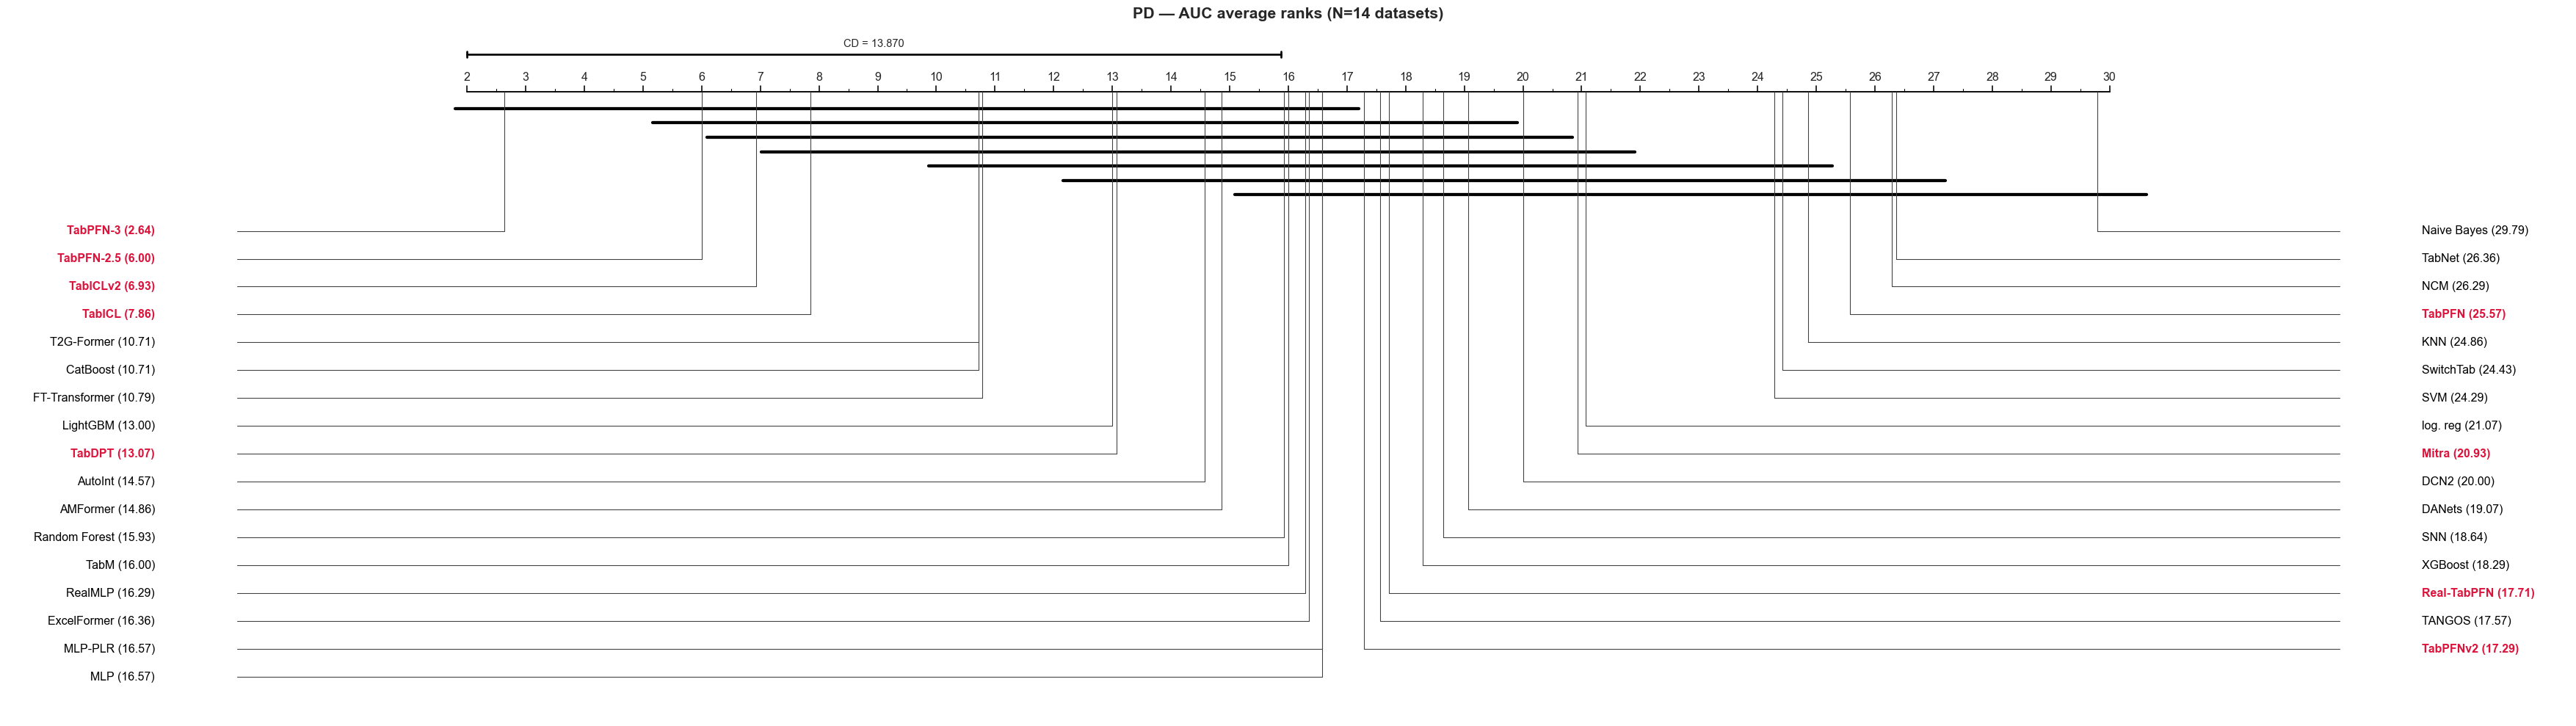

WindowsPath('C:/Users/U0152019/PhD Documents/Projects/1. TabPFN/TabPFNCredit/figures/experiment1/pd_stats/pd_cd_auc.pdf')

In [6]:
st.plot_cd_diagram(ranks, st.nemenyi_cd(mat.shape[1], mat.shape[0]),
                   title=f'PD — AUC average ranks (N={mat.shape[0]} datasets)',
                   out_path=FIGURES_DIR / 'pd_cd_auc.pdf')


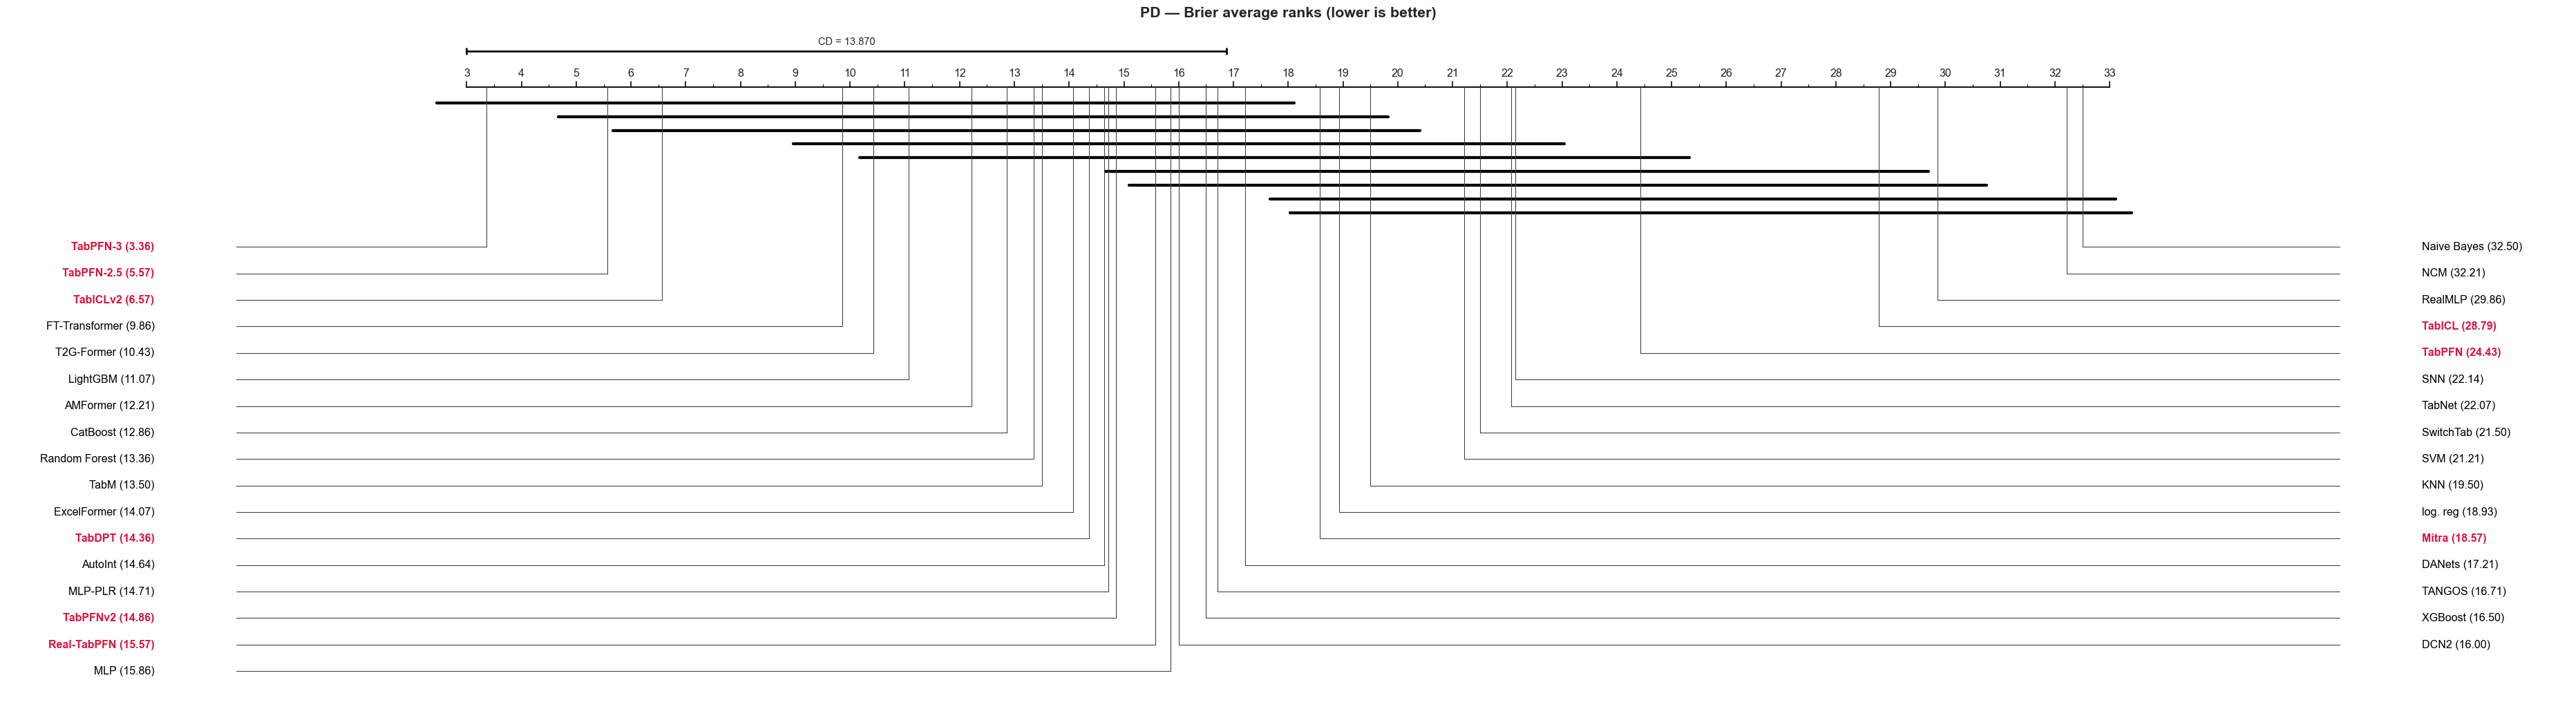

WindowsPath('C:/Users/U0152019/PhD Documents/Projects/1. TabPFN/TabPFNCredit/figures/experiment1/pd_stats/pd_cd_brier.pdf')

In [7]:
mat2 = st.metric_matrix(df, 'Brier')
st.plot_cd_diagram(st.average_ranks(mat2, higher_is_better=False),
                   st.nemenyi_cd(mat2.shape[1], mat2.shape[0]),
                   title='PD — Brier average ranks (lower is better)',
                   out_path=FIGURES_DIR / 'pd_cd_brier.pdf')


## 5. Every head-to-head — Win/Loss matrix

**What it is.** For each ordered pair, the number of datasets the row method beats the column method (cell = Win/Loss; colour = margin). Shows the *direction and consistency* of each duel regardless of significance. Ordered best-first.

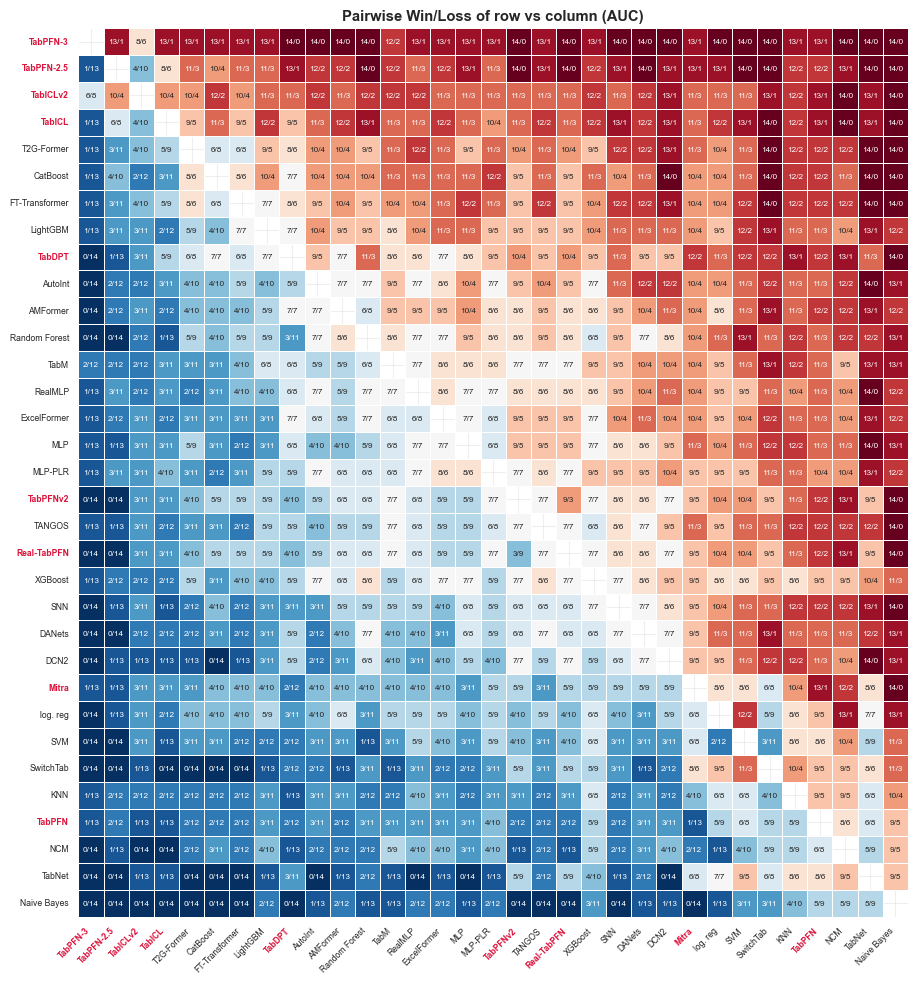

WindowsPath('C:/Users/U0152019/PhD Documents/Projects/1. TabPFN/TabPFNCredit/figures/experiment1/pd_stats/pd_winloss.pdf')

In [8]:
st.plot_wilcoxon_wl_matrix(mat, metric_name='AUC',
                           out_path=FIGURES_DIR / 'pd_winloss.pdf')


## 6. Which differences are significant? — Wilcoxon & t-test, both Holm-corrected

**What it is.** We test each pair and Holm-correct across all pairs to control the family-wise error. We report **two** complementary tests: the **Wilcoxon signed-rank** test (non-parametric; uses the sign and magnitude of per-dataset differences, no normality assumption — Demšar's recommendation) and the **paired Student's t-test** (parametric; assumes roughly normal differences — the procedure several recent tabular-ML benchmarks adopt, e.g. Ye et al. 2024; Liu et al. 2024). **How to read it.** Agreement between the two strengthens confidence; a short list after correction is expected with many methods and few datasets, and does not contradict a significant omnibus test.

In [9]:
st.significant_pairs_text(mat, test='wilcoxon', metric_name='AUC')


Significant pairwise differences in AUC (Wilcoxon signed-rank, Holm-corrected, alpha = 0.05):
  0 of 528 pairs significant.

  (none reach significance after Holm correction)


'Significant pairwise differences in AUC (Wilcoxon signed-rank, Holm-corrected, alpha = 0.05):\n  0 of 528 pairs significant.\n\n  (none reach significance after Holm correction)'

In [10]:
st.significant_pairs_text(mat, test='ttest', metric_name='AUC')


Significant pairwise differences in AUC (paired t-test, Holm-corrected, alpha = 0.05):
  1 of 528 pairs significant.

  ftt  >  dcn2    (W/L 1/13, p_holm = 0.0146)


'Significant pairwise differences in AUC (paired t-test, Holm-corrected, alpha = 0.05):\n  1 of 528 pairs significant.\n\n  ftt  >  dcn2    (W/L 1/13, p_holm = 0.0146)'

## 7. The same, as a colour map — adjusted-p-value matrix

**What it is.** For every pair, the **Shaffer-adjusted** p-value of the rank difference. Shaffer's static procedure exploits the logical dependencies among the hypotheses to be less conservative than Holm while still controlling the family-wise error (García & Herrera, 2008). **How to read it.** A **green** cell = that pair differs significantly (adjusted p < 0.05); red = not. Ordered best-first; foundation models in red.

[stat] Bergmann-Hommel skipped (k=33 > 8; exhaustive-set enumeration infeasible) -- use Shaffer instead.


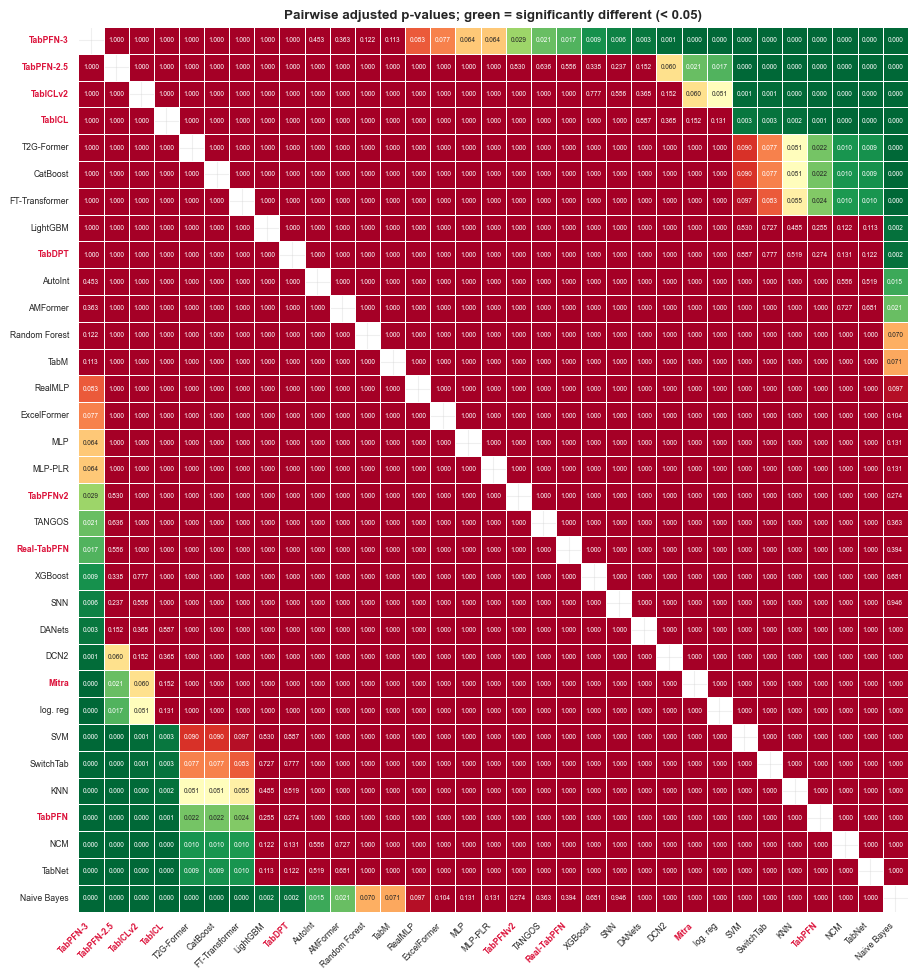

WindowsPath('C:/Users/U0152019/PhD Documents/Projects/1. TabPFN/TabPFNCredit/figures/experiment1/pd_stats/pd_significance.pdf')

In [11]:
apv = st.pairwise_apv_table(mat)
st.plot_significance_matrix(apv, mat.columns, order=list(ranks.index),
                            out_path=FIGURES_DIR / 'pd_significance.pdf')


## 8. The practical question — Bayesian signed-rank test with a ROPE

**What it is.** The **Bayesian signed-rank test** (Benavoli et al., 2014; 2017) — the Bayesian analogue of the Wilcoxon test, and the procedure **Gunnarsson et al. (2021)** used for credit scoring. With a **region of practical equivalence (ROPE)** it returns the posterior probability that one method is *practically* better, that they are equivalent, or that the other is better — and it needs **no family-wise correction**, a real advantage when many methods are compared. We compare the two leading foundation models (**TabPFN v3** vs **TabICL v2**) head-to-head, and each against strong baselines (**CatBoost**, **LogReg**).

In [12]:
import itertools as _it
FOCUS = [m for m in ('tabpfn_v3', 'tabicl_v2', 'catboost', 'LogReg') if m in mat.columns]
for x, y in _it.combinations(FOCUS, 2):
    r = st.bayesian_signed_rank_test(mat[x], mat[y], rope=0.01)


> **The story in one line.** PAMA shows who wins most; the omnibus tests confirm the differences are real; the CD diagram and Win/Loss matrix show *who* and *by how much*; Wilcoxon/t-test + Holm isolate the rigorously-significant pairs; and the Bayesian ROPE analysis turns that into the practical probability of superiority.

## Summary — the notebook's single printed report

Everything above, in text: this is the notebook's ONLY printed output, so `results/All_Results.md` is a complete text record of the analysis.

In [13]:
notebook_report(
    'Experiment 1 - PD statistics',
    notebook='Experiment1.2-PD-Stat.ipynb',
    about=('All-learner statistical comparison on PD AUC: PAMA, Friedman / Iman-Davenport / Aligned-Ranks / Quade omnibus tests, Nemenyi critical differences, win-loss counts, Holm-corrected pairwise tests and a Bayesian signed-rank ROPE analysis.'),
    sections=[
        section('Matrix shape', f'{mat.shape[1]} methods x {mat.shape[0]} datasets on AUC'),
        section('PAMA - fold-level win share per method',
                st.pama_fold_level(df_folds, 'AUC')),
        section('Full statistical battery (omnibus tests, post-hoc, Bayesian ROPE)',
                capture(st.statistical_report, df, df_folds, metric='AUC',
                        task_name='PD', higher_is_better=True)),
    ],
)

EXPERIMENT 1 - PD STATISTICS -- COMPLETE TEXT SUMMARY
Source notebook : notebooks/Experiment1.2-PD-Stat.ipynb
Contents        : All-learner statistical comparison on PD AUC: PAMA, Friedman / Iman-Davenport / Aligned-Ranks / Quade omnibus tests, Nemenyi critical differences, win-loss counts, Holm-corrected pairwise tests and a Bayesian signed-rank ROPE analysis.
Sections        : 3

This is the notebook's ONLY printed output: every table and figure-backing
number it produces is reproduced below, so results/All_Results.md is a
complete text record of the analysis.

------------------------------------------------------------------------------
[1] Matrix shape
------------------------------------------------------------------------------
33 methods x 14 datasets on AUC

------------------------------------------------------------------------------
[2] PAMA - fold-level win share per method
------------------------------------------------------------------------------
              wins  n

"==============================================================================\nEXPERIMENT 1 - PD STATISTICS -- COMPLETE TEXT SUMMARY\n==============================================================================\nSource notebook : notebooks/Experiment1.2-PD-Stat.ipynb\nContents        : All-learner statistical comparison on PD AUC: PAMA, Friedman / Iman-Davenport / Aligned-Ranks / Quade omnibus tests, Nemenyi critical differences, win-loss counts, Holm-corrected pairwise tests and a Bayesian signed-rank ROPE analysis.\nSections        : 3\n\nThis is the notebook's ONLY printed output: every table and figure-backing\nnumber it produces is reproduced below, so results/All_Results.md is a\ncomplete text record of the analysis.\n\n------------------------------------------------------------------------------\n[1] Matrix shape\n------------------------------------------------------------------------------\n33 methods x 14 datasets on AUC\n\n-----------------------------------------------